[Previous: Module 5: Trees and Heaps](05_Trees_and_Heaps.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 7: Dynamic Programming](07_Dynamic_Programming.ipynb)

# Module 6: Graphs

**Learning objectives.** After this module you can:

* represent a graph as an adjacency list and draw it;
* implement breadth-first search and use it for shortest paths in unweighted graphs and grids;
* implement depth-first search and use it to find connected components;
* implement Dijkstra's algorithm with a heap for weighted graphs, and Kahn's algorithm for dependency order.

**Prerequisites.** [Module 2](02_Arrays_Linked_Lists_Stacks_Queues.ipynb) (queues, stacks) and [Module 5](05_Trees_and_Heaps.ipynb) (heaps).

## 1. Representing a graph

A **graph** is a set of nodes (vertices) and connections (edges). Road maps, social networks, dependencies between tasks, states of a puzzle: all graphs.
The standard representation is the **adjacency list**: a dict from each node to the list of its neighbours. It uses O(V + E) memory and lists a node's neighbours in O(degree).
An adjacency matrix (V x V grid of 0/1) answers "are u and v connected?" in O(1) but costs O(V^2) memory, too much for sparse graphs.

adjacency matrix:
   A  B  C  D  E  F  G
A   .  1  1  .  .  .  .
B   1  .  .  1  1  .  .
C   1  .  .  .  .  1  .
D   .  1  .  .  .  .  .
E   .  1  .  .  .  1  .
F   .  .  1  .  1  .  1
G   .  .  .  .  .  1  .


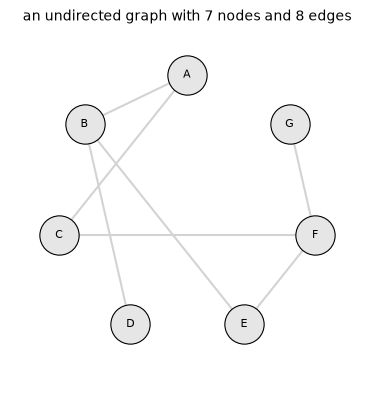

In [1]:
import random, heapq
from collections import deque
from dsalab import draw_graph, draw_grid

graph = {
    "A": ["B", "C"],
    "B": ["A", "D", "E"],
    "C": ["A", "F"],
    "D": ["B"],
    "E": ["B", "F"],
    "F": ["C", "E", "G"],
    "G": ["F"],
}
nodes = list(graph)
print("adjacency matrix:")
print("   " + "  ".join(nodes))
for u in nodes:
    print(u, " ", "  ".join("1" if v in graph[u] else "." for v in nodes))
draw_graph(graph, title="an undirected graph with 7 nodes and 8 edges")

## 2. Breadth-first search: rings of distance

**BFS** starts at a node and explores in layers: first all neighbours (distance 1), then their neighbours (distance 2), and so on.
It uses a **queue**: pop a node, push its unvisited neighbours. Because layers come out in order, the first time BFS reaches a node it has found
a **shortest path** to it (fewest edges). Record each node's parent and you can walk the path back.

visit order: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
distances:   {'A': 0, 'B': 1, 'C': 1, 'D': 2, 'E': 2, 'F': 2, 'G': 3}
path A to G: ['A', 'C', 'F', 'G']


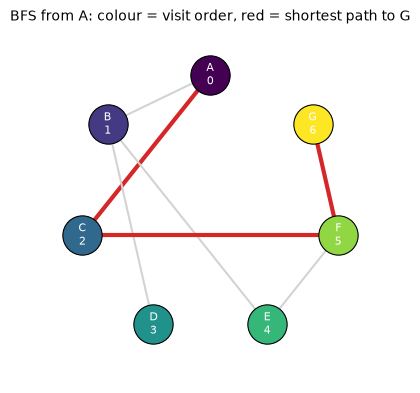

In [2]:
def bfs(graph, start):
    dist, parent, order = {start: 0}, {start: None}, []
    queue = deque([start])
    while queue:
        node = queue.popleft()
        order.append(node)
        for nb in graph[node]:
            if nb not in dist:
                dist[nb] = dist[node] + 1
                parent[nb] = node
                queue.append(nb)
    return order, dist, parent

def path_to(parent, target):
    path = []
    while target is not None:
        path.append(target)
        target = parent[target]
    return path[::-1]

order, dist, parent = bfs(graph, "A")
print("visit order:", order)
print("distances:  ", dist)
print("path A to G:", path_to(parent, "G"))
draw_graph(graph, order=order, path=path_to(parent, "G"), title="BFS from A: colour = visit order, red = shortest path to G")

## 3. Depth-first search: go deep, then back up

**DFS** dives along one path as far as it can, then backtracks. Recursion gives it for free (the call stack is the stack); an explicit stack works too.
DFS does not find shortest paths, but it is the tool for questions about **structure**: which nodes are reachable, how many **connected components** there are,
whether there is a cycle, and (Section 6) in what order to do dependent tasks.

DFS from A: ['A', 'B', 'D', 'E', 'F', 'C', 'G']
components: [['A', 'B', 'C'], ['X', 'Y', 'Z'], ['Q']]


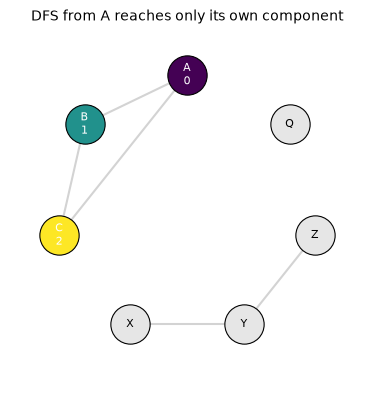

In [3]:
def dfs(graph, node, visited=None, order=None):
    visited = set() if visited is None else visited
    order = [] if order is None else order
    visited.add(node)
    order.append(node)
    for nb in graph[node]:
        if nb not in visited:
            dfs(graph, nb, visited, order)
    return order

print("DFS from A:", dfs(graph, "A"))

def components(graph):
    seen, comps = set(), []
    for node in graph:
        if node not in seen:
            comp = dfs(graph, node, seen)
            comps.append(comp)
    return comps

two = {"A": ["B", "C"], "B": ["A", "C"], "C": ["A", "B"], "X": ["Y"], "Y": ["X", "Z"], "Z": ["Y"], "Q": []}
print("components:", components(two))
draw_graph(two, order=dfs(two, "A"), title="DFS from A reaches only its own component")

### Lab: Graph Explorer

Step through BFS and DFS on the same graph from the same start. Watch the queue fill up layer by layer for BFS, and the stack dive for DFS.
Then switch to "two components" and start from X.

Graph Explorer (static preview). Run this cell in JupyterLab for the interactive version.


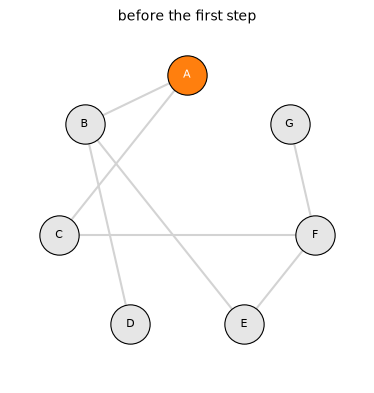

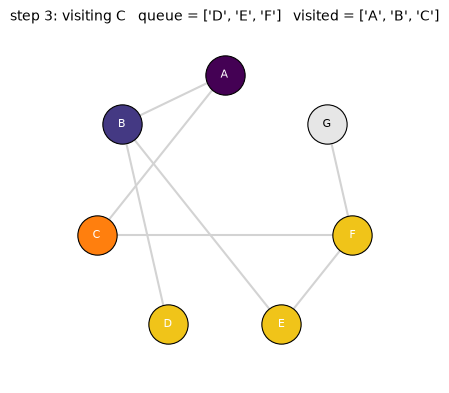

In [4]:
from dsalab import graph_explorer

graph_explorer()

## 4. Grids are graphs: escape the maze

A grid is a graph where each cell's neighbours are the cells above, below, left and right. BFS on a grid gives shortest paths through a maze.
The cell below generates a random maze and finds the shortest route from the top-left to the bottom-right corner. Change the seed and the wall density.

In [5]:
%matplotlib inline
from ipywidgets import interact, IntSlider, FloatSlider

def make_grid(n, wall_prob, seed):
    rng = random.Random(seed)
    grid = [[1 if rng.random() < wall_prob else 0 for _ in range(n)] for _ in range(n)]
    grid[0][0] = grid[n - 1][n - 1] = 0
    return grid

def bfs_grid(grid, start, goal):
    n, m = len(grid), len(grid[0])
    parent, queue = {start: None}, deque([start])
    while queue:
        r, c = queue.popleft()
        if (r, c) == goal:
            break
        for dr, dc in [(1, 0), (-1, 0), (0, 1), (0, -1)]:
            nr, nc = r + dr, c + dc
            if 0 <= nr < n and 0 <= nc < m and not grid[nr][nc] and (nr, nc) not in parent:
                parent[(nr, nc)] = (r, c)
                queue.append((nr, nc))
    if goal not in parent:
        return None, parent
    path, cur = [], goal
    while cur is not None:
        path.append(cur); cur = parent[cur]
    return path[::-1], parent

def show_maze(seed, wall_prob):
    n = 15
    grid = make_grid(n, wall_prob, seed)
    path, visited = bfs_grid(grid, (0, 0), (n - 1, n - 1))
    title = f"shortest path: {len(path) - 1} steps, {len(visited)} cells explored" if path else f"no path, {len(visited)} cells explored"
    display(draw_grid(grid, visited=visited, path=path, title=title))

interact(show_maze, seed=IntSlider(min=0, max=30, value=3, description="seed"),
         wall_prob=FloatSlider(min=0, max=0.5, step=0.05, value=0.25, description="walls"));

interactive(children=(IntSlider(value=3, description='seed', max=30), FloatSlider(value=0.25, description='wal…

## 5. Weighted graphs: Dijkstra

When edges have costs (distance, time, money), fewest edges is no longer cheapest. **Dijkstra's algorithm** grows the set of settled nodes in order of
distance from the start, always extending from the closest unsettled node. A **min-heap** of (distance, node) pairs supplies that node in O(log n),
giving O((V + E) log V) overall. It requires non-negative weights.

distances from A: {'A': 0, 'B': 4, 'C': 2, 'D': 9, 'E': 5, 'F': 20}
cheapest A to F: ['A', 'C', 'E', 'D', 'F'] cost 20
fewest edges A to F: ['A', 'B', 'D', 'F'] (BFS ignores the weights)


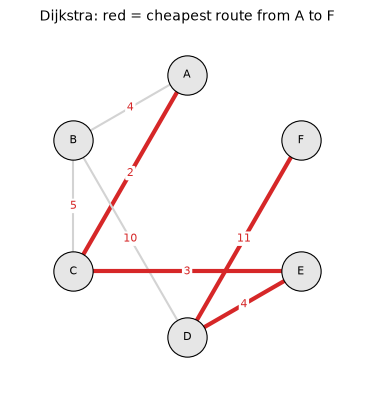

In [6]:
weighted = {
    "A": {"B": 4, "C": 2},
    "B": {"A": 4, "C": 5, "D": 10},
    "C": {"A": 2, "B": 5, "E": 3},
    "D": {"B": 10, "E": 4, "F": 11},
    "E": {"C": 3, "D": 4},
    "F": {"D": 11},
}

def dijkstra(graph, source):
    dist = {v: float("inf") for v in graph}
    dist[source] = 0
    parent = {source: None}
    heap = [(0, source)]
    while heap:
        d, node = heapq.heappop(heap)
        if d > dist[node]:                     # stale entry, already improved
            continue
        for nb, wgt in graph[node].items():
            nd = d + wgt
            if nd < dist[nb]:
                dist[nb], parent[nb] = nd, node
                heapq.heappush(heap, (nd, nb))
    return dist, parent

dist, parent = dijkstra(weighted, "A")
print("distances from A:", dist)
print("cheapest A to F:", path_to(parent, "F"), "cost", dist["F"])
print("fewest edges A to F:", path_to(bfs({u: list(v) for u, v in weighted.items()}, "A")[2], "F"), "(BFS ignores the weights)")
draw_graph(weighted, weighted=True, path=path_to(parent, "F"), title="Dijkstra: red = cheapest route from A to F")

> **What to notice.** BFS goes A, B, D, F in three edges costing 25. Dijkstra takes five edges costing 20. Different questions, different algorithms.

## 6. Order of dependencies: topological sort

A **directed acyclic graph** (DAG) of tasks, where an edge u to v means "u before v", has a **topological order**: a sequence in which every task comes after
its prerequisites. **Kahn's algorithm** repeatedly removes a node with no remaining incoming edges. If nodes are left over, there is a cycle and no valid order exists.

In [7]:
courses = {"maths": ["physics", "cs101"], "cs101": ["algorithms", "databases"], "physics": ["quantum"],
           "algorithms": ["quantum"], "databases": [], "quantum": []}

def topological_order(dag):
    indegree = {v: 0 for v in dag}
    for u in dag:
        for v in dag[u]:
            indegree[v] += 1
    ready = deque(v for v in dag if indegree[v] == 0)
    order = []
    while ready:
        u = ready.popleft()
        order.append(u)
        for v in dag[u]:
            indegree[v] -= 1
            if indegree[v] == 0:
                ready.append(v)
    if len(order) < len(dag):
        raise ValueError("cycle detected, no valid order")
    return order

print("take the courses in this order:", topological_order(courses))

take the courses in this order: ['maths', 'physics', 'cs101', 'algorithms', 'databases', 'quantum']


## Try it yourself

**Exercise 1.** Count the islands in a grid of 0s (water) and 1s (land): the number of connected components of land cells. DFS from every unvisited land cell.

**Exercise 2.** Check whether a graph is **bipartite** (2-colourable) with BFS: colour the start 0, neighbours 1, and so on; a conflict means it is not.

**Exercise 3.** Word ladder: from `"cold"` to `"warm"` changing one letter at a time through a given dictionary. Build the graph implicitly and BFS.

**Exercise 4 (challenge).** Modify Dijkstra to stop as soon as the target is popped, and count how many heap pops it saved on the graph above.

<details><summary>Solutions</summary>

```python
# Exercise 1
def count_islands(grid):
    n, m, seen = len(grid), len(grid[0]), set()
    def dfs(r, c):
        if not (0 <= r < n and 0 <= c < m) or grid[r][c] == 0 or (r, c) in seen: return
        seen.add((r, c))
        for dr, dc in [(1, 0), (-1, 0), (0, 1), (0, -1)]: dfs(r + dr, c + dc)
    islands = 0
    for r in range(n):
        for c in range(m):
            if grid[r][c] == 1 and (r, c) not in seen:
                dfs(r, c); islands += 1
    return islands
print(count_islands([[1, 1, 0, 0], [0, 1, 0, 1], [0, 0, 0, 1], [1, 0, 0, 0]]))   # 3

# Exercise 2
def is_bipartite(graph):
    colour = {}
    for s in graph:
        if s in colour: continue
        colour[s] = 0; queue = deque([s])
        while queue:
            u = queue.popleft()
            for v in graph[u]:
                if v not in colour: colour[v] = 1 - colour[u]; queue.append(v)
                elif colour[v] == colour[u]: return False
    return True
print(is_bipartite(graph), is_bipartite({"A": ["B", "C"], "B": ["A", "C"], "C": ["A", "B"]}))

# Exercise 3
def word_ladder(start, goal, words):
    words, queue, parent = set(words) | {start, goal}, deque([start]), {start: None}
    while queue:
        w = queue.popleft()
        if w == goal: return path_to(parent, w)
        for i in range(len(w)):
            for ch in "abcdefghijklmnopqrstuvwxyz":
                nxt = w[:i] + ch + w[i + 1:]
                if nxt in words and nxt not in parent: parent[nxt] = w; queue.append(nxt)
print(word_ladder("cold", "warm", ["cord", "card", "ward", "word", "worm"]))
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [8]:
from dsalab import quiz

quiz(6)

Checkpoint quiz, Module 6 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. Breadth-first search keeps its frontier in
    a) a stack
    b) a queue
    c) a heap
    d) a set only

Q2. In an unweighted graph, BFS from a start node finds
    a) a shortest path (fewest edges) to every reachable node
    b) the cheapest weighted path
    c) all cycles
    d) a spanning tree of maximum weight

Q3. Dijkstra's algorithm requires
    a) a tree
    b) non-negative edge weights
    c) an undirected graph
    d) at most 100 nodes

Q4. An adjacency list for a graph with V vertices and E edges uses memory
    a) O(V)
    b) O(V + E)
    c) O(V^2)
    d) O(E^2)


## Key takeaways

* Adjacency lists (dict of lists) are the default representation: O(V + E) memory.
* BFS with a queue explores by distance and finds shortest paths in unweighted graphs and grids.
* DFS with a stack or recursion explores by depth and answers structural questions: reachability, components, cycles, ordering.
* Dijkstra with a heap handles non-negative weights; Kahn's algorithm orders a DAG.

**Next:** the last big idea, remembering answers to subproblems. [Module 7](07_Dynamic_Programming.ipynb).

[Previous: Module 5: Trees and Heaps](05_Trees_and_Heaps.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 7: Dynamic Programming](07_Dynamic_Programming.ipynb)